<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 6B: *Fire Spread Tuning*
##### Version Number: 4.0
---
### Contents  
> 1. *Random Forest*
> 3. *XGBoost*
> 4. *Export Optimum Configurations*
---
### Notes
This module **automatically** finds the optimal configuration of models based on the average F1 score of all three categories.

**WARNING** this module is very computation heavy
- Start with a **baseline model** for comparison.
- Test with multi-classification **tree-based models** (Random Forest, XGBoost) and LGBM.
- Use kfold **cross-validation** to tune hyperparameters for each model.
- Export optimal models

---
### Inputs

---
### Outputs  

`model_parameters.csv` - optimal parameters for each of the three models

---
### User Created Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---

### Third Party Dependencies

In [2]:
# Core Python libraries
import numpy as np
import pandas as pd
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Metrics
from sklearn.metrics import classification_report

# Style
sns.set(style='whitegrid')
plt.rcParams["figure.dpi"] = 100

---

### Load File

In [3]:
X_spread = pd.read_csv('../data/processed/X_spread.csv')
y_spread = pd.read_csv('../data/processed/y_spread.csv').squeeze()

In [4]:
reform = pd.concat([X_spread,y_spread], axis=1)
subset = subset_df(reform, 'Target_Spread', 600)

y = subset['Target_Spread']
X = subset.drop(columns='Target_Spread')

---

## 1. Random Forest Classifier

This section evaluates Hypertuning and class-balancing options for SciKitLearns **RandomForestClassifier**. Options are tested utilizing kfold validation. 
- `n_estimators` [50, 100, 150]
- `max_depth` [5, 10, 15, 20]
- `min_samples_split_values` = [2, 5, 10, 20, 50]
- `max_features` ['sqrt', 'log2']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14, stratify=y)

### 1.1 Hyperparameter Tuning

#### Number of Estimators (n_estimators)

RF: n_estimators = 50 | Average F1 score = 0.5554


RF: n_estimators = 100 | Average F1 score = 0.5471


RF: n_estimators = 150 | Average F1 score = 0.5524


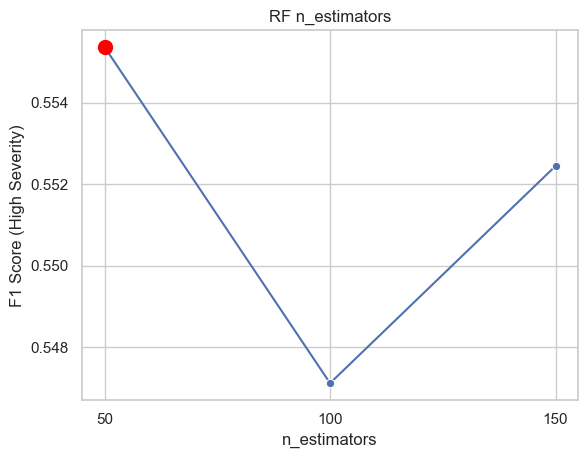

In [6]:
# Define parameter grid
estimators = [50, 100, 150]
optimum_n_estimator = test_values('RF','n_estimators',estimators,X_train, y_train)

#### Maximum Tree Depth (max_depth)

RF: max_depth = 5 | Average F1 score = 0.5352


RF: max_depth = 10 | Average F1 score = 0.5487


RF: max_depth = 15 | Average F1 score = 0.5565


RF: max_depth = 20 | Average F1 score = 0.5457


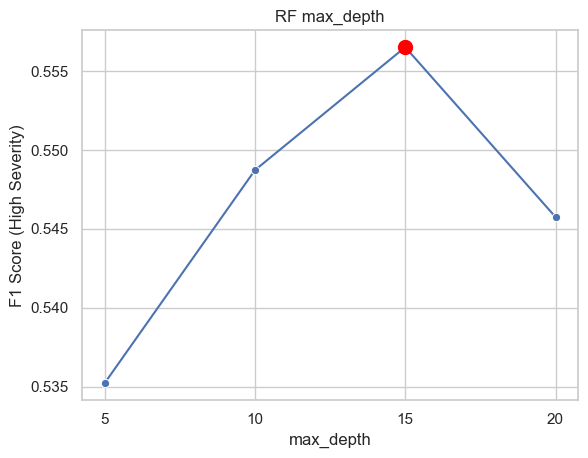

In [7]:
# Define parameter grid
max_depth = [5, 10, 15, 20] 
optimum_max_depth = test_values('RF','max_depth',max_depth,X_train, y_train)

#### Maximum Features (max_features)

RF: max_features = sqrt | Average F1 score = 0.5554


RF: max_features = log2 | Average F1 score = 0.5489


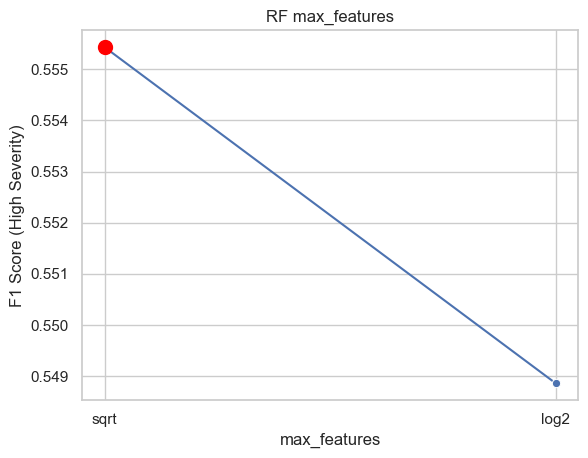

In [8]:
# Define parameter grid
max_features = ['sqrt', 'log2']
optimum_max_features = test_values('RF','max_features',max_features,X_train, y_train)

#### Minimum Sample Split  (min_samples)

RF: min_samples_split = 2 | Average F1 score = 0.5366


RF: min_samples_split = 5 | Average F1 score = 0.5578


RF: min_samples_split = 10 | Average F1 score = 0.5607


RF: min_samples_split = 20 | Average F1 score = 0.5525


RF: min_samples_split = 50 | Average F1 score = 0.5447


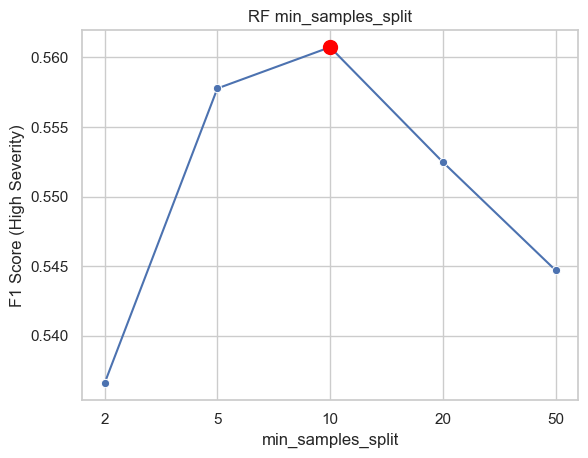

In [9]:
# Define parameter grid
min_samples_split_values = [2, 5, 10, 20, 50] 
optimum_min_samples_split = test_values('RF','min_samples_split',min_samples_split_values,X_train, y_train)

### 1.2 Final Random Forest Model

In [10]:
RF_parameters = {
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'min_samples_split': optimum_min_samples_split,
    'max_features': optimum_max_features,
    'class_weight':'balanced'
}

pd.DataFrame([RF_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum Random Forest Parameters")

n_estimators,max_depth,min_samples_split,max_features,class_weight
50,15,10,sqrt,balanced


---

## 3. XGBoost Classifier

This section trains an XGBoost classifier using grid-based hyperparameter tuning and evaluates performance under different sampling strategies.

### 3.2 Hyperparameter Tuning

#### n_estimators

XGB: n_estimators = 50 | Average F1 score = 0.5555


XGB: n_estimators = 100 | Average F1 score = 0.5625


XGB: n_estimators = 150 | Average F1 score = 0.5656


XGB: n_estimators = 200 | Average F1 score = 0.5696


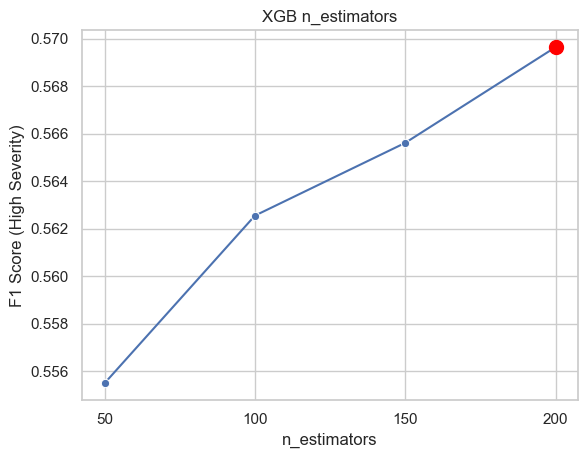

In [11]:
n_estimators = [50, 100, 150, 200]
optimum_n_estimator = test_values('XGB','n_estimators', n_estimators, X_train, y_train)

#### learning_rate

XGB: learning_rate = 0.1 | Average F1 score = 0.5451


XGB: learning_rate = 0.2 | Average F1 score = 0.5391


XGB: learning_rate = 0.3 | Average F1 score = 0.5353


XGB: learning_rate = 0.4 | Average F1 score = 0.5339


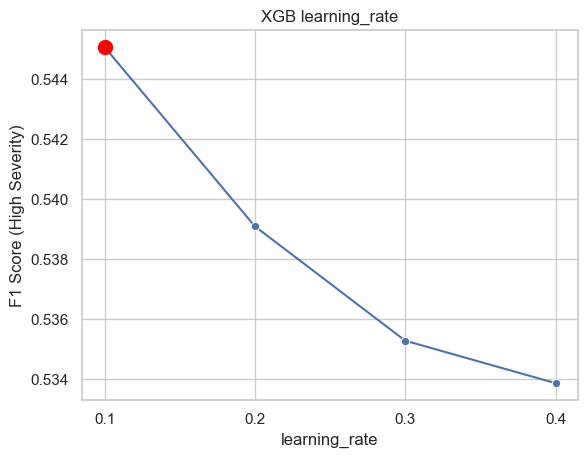

In [12]:
learning_rates = [0.1, 0.2, 0.3, 0.4]
optimum_learning_rate = test_values('XGB','learning_rate', learning_rates, X_train, y_train)

#### max_depth

XGB: max_depth = 3 | Average F1 score = 0.5663


XGB: max_depth = 4 | Average F1 score = 0.5696


XGB: max_depth = 5 | Average F1 score = 0.5573


XGB: max_depth = 6 | Average F1 score = 0.5601


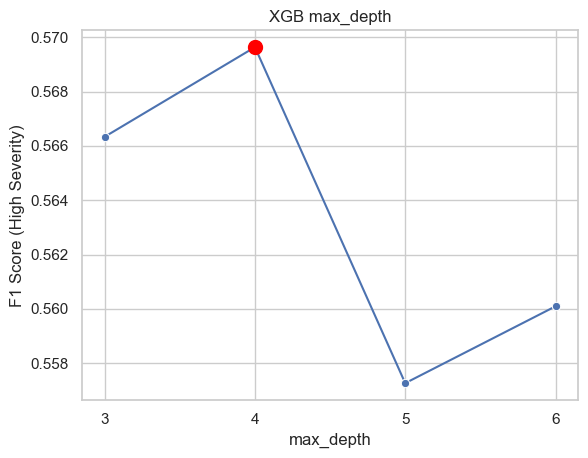

In [13]:
max_depths = [3, 4, 5, 6]
optimum_max_depth = test_values('XGB','max_depth', max_depths, X_train, y_train)

### 3.3 Final XGBoost Model

In [14]:
XGB_parameters = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'learning_rate': optimum_learning_rate,
    'verbosity': 0
}

# Create DataFrame and format display
pd.DataFrame([XGB_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum XGBoost Parameters")

objective,num_class,n_estimators,max_depth,learning_rate,verbosity
multi:softmax,3,200,4,0.100000,0


---

## 4. Export Data

In [15]:
model_params_spread = {
    'Random Forest': RF_parameters,
    'XGBoost': XGB_parameters
}


In [16]:
# Save to CSV

with open('model_parameters_spread.json', 'w') as f:
    json.dump(model_params_spread, f, indent=4)
    
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
